Loaded: (43405, 75)
Default rate: 0.0482
XGBoost version: 1.7.6
Total features : 68
  Financial    : 10
  Attr (raw)   : 54
  Override     : 4
Samples        : 43,405
Positive rate  : 0.0482
scale_pos_weight: 19.76

5-Fold CV Metrics (XGBoost):
  ROC_AUC   : 0.9612
  PR_AUC    : 0.7639
  Brier     : 0.0480
Saved: ../results/tables/07_xgb_cv_metrics.csv
Model saved: models/xgboost/xgb_override.pkl


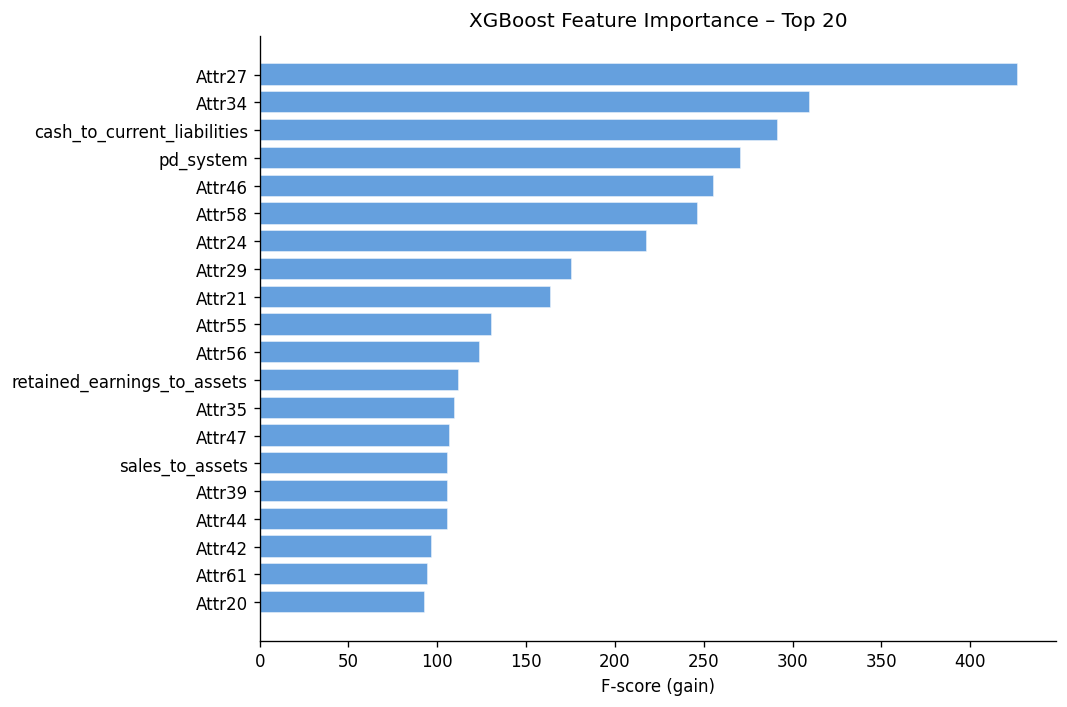

Figure saved: 10_xgb_feature_importance.png
Saved: ../results/tables/08_feature_importance.csv

Override feature ranks:
  pd_system           : rank   4  gain = 271.0
  grade_ordinal       : rank  61  gain = 18.0
  grade_diff          : rank  56  gain = 28.0
  override_flag       : rank  68  gain = 3.0


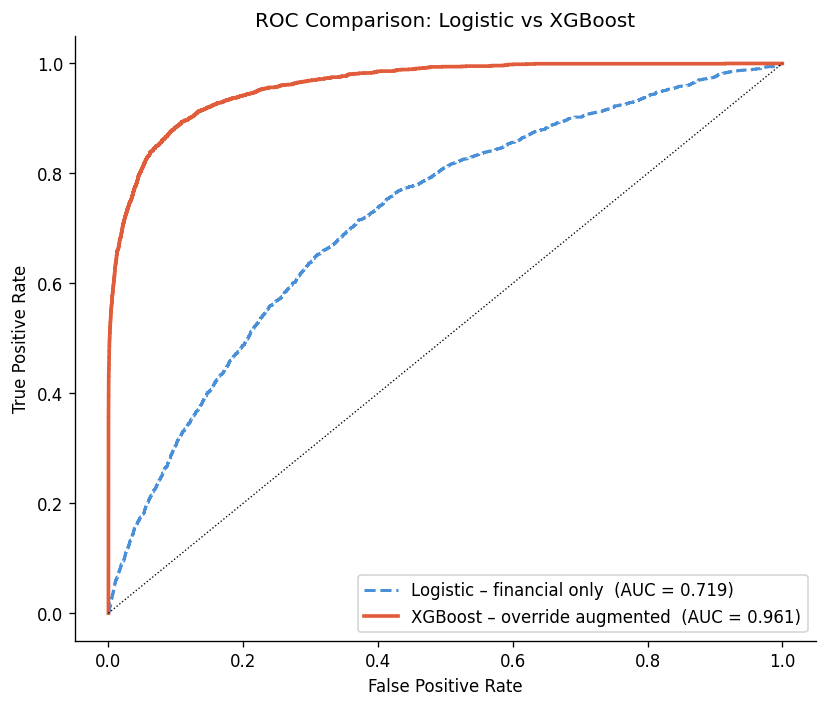

AUC – Logistic : 0.7191
AUC – XGBoost  : 0.9612
ΔAUC           : +0.2421

Default rate by override direction × risk tier:


n                        default_rate                  \
risk_tier             Low Medium  High Very high          Low  Medium    High   
override_direction                                                              
downgrade            6787   1408   537       280       0.0012  0.0163  0.0857   
none                18048   5172  2948      1957       0.0021  0.0159  0.0719   
upgrade              3221   1303   996       748       0.0031  0.0153  0.0783   

                              
risk_tier          Very high  
override_direction            
downgrade             0.5929  
none                  0.5284  
upgrade               0.5000

Saved: ../results/tables/09_subgroup_analysis.csv


In [2]:
# NB06_ml_model.ipynb

# %% [markdown]
# # NB06 – Machine Learning Model: XGBoost
# **Purpose:** Train an XGBoost classifier on the override-augmented dataset.
# This model prioritises predictive accuracy and feeds into the
# SHAP explainability analysis in NB07.
#
# **Input:**  `data/processed/override_data.parquet`
# **Output:**
# - `models/xgboost/xgb_override.pkl`
# - `results/tables/07_xgb_cv_metrics.csv`
# - `results/tables/08_feature_importance.csv`
# - `results/figures/10_xgb_feature_importance.png`
# - `results/figures/11_roc_xgb_vs_logit.png`

# %%
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                              average_precision_score, roc_curve)

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
MODEL_DIR = "../models/xgboost/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_parquet(PROC_DIR + "override_data.parquet")
print(f"Loaded: {df.shape}")
print(f"Default rate: {df['default'].mean():.4f}")

import xgboost as xgb_lib
print(f"XGBoost version: {xgb_lib.__version__}")

# %% [markdown]
# ## 1. Feature matrix

# %%
FINANCIAL_COLS = [
    "net_profit_to_assets",
    "total_liabilities_to_assets",
    "working_capital_to_assets",
    "current_assets_to_short_liabilities",
    "cash_to_current_liabilities",
    "retained_earnings_to_assets",
    "ebit_to_assets",
    "book_value_equity_to_liabilities",
    "sales_to_assets",
    "equity_to_assets",
]
FINANCIAL_COLS = [c for c in FINANCIAL_COLS if c in df.columns]

ATTR_COLS = [c for c in df.columns if c.startswith("Attr")]

OVERRIDE_COLS = ["pd_system", "grade_ordinal", "grade_diff", "override_flag"]
OVERRIDE_COLS = [c for c in OVERRIDE_COLS if c in df.columns]

FEATURE_COLS = list(dict.fromkeys(FINANCIAL_COLS + ATTR_COLS + OVERRIDE_COLS))

X = df[FEATURE_COLS].fillna(0)
y = df["default"]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"  Financial    : {len(FINANCIAL_COLS)}")
print(f"  Attr (raw)   : {len(ATTR_COLS)}")
print(f"  Override     : {len(OVERRIDE_COLS)}")
print(f"Samples        : {len(X):,}")
print(f"Positive rate  : {y.mean():.4f}")

# %% [markdown]
# ## 2. XGBoost with 5-fold cross-validation
# Note: use_label_encoder removed in XGBoost >= 1.6

# %%
scale_pos = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

xgb = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    eval_metric      = "logloss",
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(xgb, X, y, cv=cv, method="predict_proba")[:, 1]

metrics = {
    "ROC_AUC" : round(roc_auc_score(y, oof_proba), 4),
    "PR_AUC"  : round(average_precision_score(y, oof_proba), 4),
    "Brier"   : round(brier_score_loss(y, oof_proba), 4),
}

print("\n5-Fold CV Metrics (XGBoost):")
for k, v in metrics.items():
    print(f"  {k:10s}: {v:.4f}")

pd.DataFrame([metrics]).to_csv(TABLE_DIR + "07_xgb_cv_metrics.csv", index=False)
print(f"Saved: {TABLE_DIR}07_xgb_cv_metrics.csv")

# %% [markdown]
# ## 3. Refit on full data and save model

# %%
xgb.fit(X, y)
joblib.dump({"model": xgb, "feature_cols": FEATURE_COLS},
            MODEL_DIR + "xgb_override.pkl")
print("Model saved: models/xgboost/xgb_override.pkl")

# %% [markdown]
# ## 4. Feature importance (gain)

# %%
importance = (pd.Series(xgb.get_booster().get_fscore(), name="gain")
                .sort_values(ascending=False))

top20 = importance.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.index[::-1], top20.values[::-1],
        color="#4A90D9", alpha=0.85, edgecolor="white")
ax.set_xlabel("F-score (gain)")
ax.set_title("XGBoost Feature Importance – Top 20")
plt.tight_layout()
plt.savefig(FIG_DIR + "10_xgb_feature_importance.png", bbox_inches="tight")
plt.show()
print("Figure saved: 10_xgb_feature_importance.png")

importance.to_csv(TABLE_DIR + "08_feature_importance.csv", header=True)
print(f"Saved: {TABLE_DIR}08_feature_importance.csv")

print("\nOverride feature ranks:")
for col in OVERRIDE_COLS:
    rank = importance.index.tolist().index(col) + 1 if col in importance.index else "N/A"
    val  = importance.get(col, 0)
    print(f"  {col:20s}: rank {rank:>3}  gain = {val:.1f}")

# %% [markdown]
# ## 5. ROC comparison: Logistic vs XGBoost

# %%
X_logit = df[FINANCIAL_COLS].fillna(0)
p_logit = cross_val_predict(
    LogisticRegression(C=0.1, max_iter=500, class_weight="balanced"),
    X_logit, y, cv=cv, method="predict_proba"
)[:, 1]

auc_logit = roc_auc_score(y, p_logit)
auc_xgb   = roc_auc_score(y, oof_proba)

fpr_l, tpr_l, _ = roc_curve(y, p_logit)
fpr_x, tpr_x, _ = roc_curve(y, oof_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_l, tpr_l, "--", color="#4A90D9", linewidth=1.8,
        label=f"Logistic – financial only  (AUC = {auc_logit:.3f})")
ax.plot(fpr_x, tpr_x,  "-", color="#E05C3A", linewidth=2.2,
        label=f"XGBoost – override augmented  (AUC = {auc_xgb:.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Comparison: Logistic vs XGBoost")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR + "11_roc_xgb_vs_logit.png", bbox_inches="tight")
plt.show()

print(f"AUC – Logistic : {auc_logit:.4f}")
print(f"AUC – XGBoost  : {auc_xgb:.4f}")
print(f"ΔAUC           : {auc_xgb - auc_logit:+.4f}")

# %% [markdown]
# ## 6. Subgroup analysis: default rate by override direction × risk tier

# %%
df["oof_proba"] = oof_proba
df["risk_tier"] = pd.cut(
    oof_proba,
    bins   = [0, 0.1, 0.3, 0.6, 1.0],
    labels = ["Low", "Medium", "High", "Very high"],
)

subgroup = (
    df.groupby(["override_direction", "risk_tier"], observed=True)["default"]
      .agg(n="count", default_rate="mean")
      .round(4)
      .unstack("risk_tier")
)

print("\nDefault rate by override direction × risk tier:")
display(subgroup)
subgroup.to_csv(TABLE_DIR + "09_subgroup_analysis.csv")
print(f"Saved: {TABLE_DIR}09_subgroup_analysis.csv")